# Lab 3: Clustering, Association Rules, and Recommenders
**Name:** Chloe Barker  
**Course:** DS 7331  

## Reproducibility

In [1]:
# Required packages
import sys, platform, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version

# Global random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Environment and package versions
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)
print("scikit-learn version:", sklearn_version)

# Sources for datasets
CLUSTERING_DATA_URL = "https://www.kaggle.com/datasets/chik0di/health-and-lifestyle-dataset"
ASSOCIATION_DATA_URL = "https://www.kaggle.com/datasets/carrie1/ecommerce-data"

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
Platform: macOS-26.1-arm64-arm-64bit-Mach-O
NumPy version: 2.1.3
pandas version: 2.2.3
scikit-learn version: 1.6.1


## Part 1: Data Ingestion and Documentation

### Clustering Dataset

In [2]:
clustering_df = pd.read_csv("/Users/chloebarker/Downloads/Artificial_Intelligence/Labs/Lab-3/health_lifestyle_dataset.csv")
display(clustering_df.head())

print("Clustering dataset info:")
clustering_df.info()
display(clustering_df.isna().sum())

# Label distribution
print("\nLabel distribution (disease_risk):")
display(clustering_df["disease_risk"].value_counts(normalize=True).rename("proportion"))

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


Clustering dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 n

id                   0
age                  0
gender               0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
smoker               0
alcohol              0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
family_history       0
disease_risk         0
dtype: int64


Label distribution (disease_risk):


disease_risk
0    0.75179
1    0.24821
Name: proportion, dtype: float64

**Clustering Health & Lifestyle Dataset Data Card:**
- **Source/URL:** [Kaggle – Health & Lifestyle Dataset](https://www.kaggle.com/datasets/chik0di/health-and-lifestyle-dataset)  
- **License:** CC0: Public Domain
- **Shape (rows × columns):** 100,000 × 16  
- **Variable dictionary:**

| Variable Name | Type | Description | Expected Domain |
|---|---|---|---|
| id | Numeric | Unique identifier for each participant | Positive integers |
| age | Numeric | Age of the individual (years) | 18-90+ |
| gender | Categorical | Gender identity | {Male, Female} |
| bmi | Numeric | Body Mass Index (kg/m²) | ~15-45 |
| daily_steps | Numeric | Number of steps taken per day | ≥ 0 |
| sleep_hours | Numeric | Hours of sleep per night | 0-12 |
| water_intake_l | Numeric | Daily water intake (liters) | ≥ 0 |
| calories_consumed | Numeric | Estimated daily calories consumed (kcal/day) | ≥ 0 |
| smoker | Categorical | Smoking status | {0 = No, 1 = Yes} |
| alcohol | Categorical | Alcohol consumption status | {0 = No, 1 = Yes} |
| resting_hr | Numeric | Resting heart rate (beats per minute) | ≥ 0 (typical adult range ~40–120) |
| systolic_bp | Numeric | Systolic blood pressure (mmHg) | ≥ 0 |
| diastolic_bp | Numeric | Diastolic blood pressure (mmHg) | ≥ 0 |
| cholesterol | Numeric | Total cholesterol (mg/dL) | ≥ 0 |
| family_history | Categorical | Family history of disease | {0 = No, 1 = Yes} |
| disease_risk | Target (Categorical) | Overall disease risk classification | {0 = Low Risk, 1 = High Risk} |

- **Collection process & biases:**  
This dataset is synthetically generated, meaning no real patient data was collected. This eliminates risks of personal privacy violations but also introduces important considerations:
- The distributions and relationships between variables reflect designer assumptions, not real-world medical datasets.
- Because it lacks real demographic variety, it cannot be used to draw clinical conclusions.
- Biases may arise unintentionally based on generation rules (e.g., linking BMI strongly to disease_risk).
- It is appropriate for teaching, modeling practice, and algorithmic benchmarking, not for health policy or medical decision-making

### Transactional / interaction dataset

In [3]:
interactions_df = pd.read_csv("/Users/chloebarker/Downloads/Artificial_Intelligence/Labs/Lab-3/Online_Retail.csv")
display(interactions_df.head())

print("Transactional / interaction dataset info:")
interactions_df.info()
display(interactions_df.isna().sum())

# Basic interaction counts
n_users = interactions_df["CustomerID"].nunique(dropna=True)
n_items = interactions_df["StockCode"].nunique(dropna=True)
n_interactions = len(interactions_df)

print("\nBasic counts:")
print(f"Unique customers (CustomerID, non-null): {n_users}")
print(f"Unique items (StockCode): {n_items}")
print(f"Total interactions (rows): {n_interactions}")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


Transactional / interaction dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Basic counts:
Unique customers (CustomerID, non-null): 4372
Unique items (StockCode): 4070
Total interactions (rows): 541909


**Transactional / Interaction Dataset Data Card (Online Retail):**
- **Source/URL:** [UCI – Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)
- **License:** Creative Commons Attribution 4.0 International (CC BY 4.0)
- **Shape (transactions × features):** 541,909 transactions × 8 variables
  - Approx. **4,372 unique customers** and **4,070 unique products** in this version.
- **Variable dictionary:**

| Variable Name | Role | Type | Description |
|---|---|---|---|
| InvoiceNo | ID | Categorical | Invoice number; 6-digit code per transaction. If it starts with letter 'C', the invoice is a cancellation. |
| StockCode | Item ID | Categorical | Product code uniquely assigned to each distinct product |
| Description | Feature | Categorical | Product name / description |
| Quantity | Feature | Integer | Number of units purchased per transaction |
| InvoiceDate | Feature | Date/Time | Timestamp of transaction |
| UnitPrice | Feature | Continuous | Product price per unit (£)| 
| CustomerID | User ID | Categorical | 5-digit unique customer identifier |
| Country | Feature | Categorical | Customer’s country of residence |

- **Collection process & biases:**  
 This dataset represents real transactions from a UK-based online retailer (2010–2011). While valuable for unsupervised modeling, users should consider:
- Customer demographics are unavailable, creating potential confounding factors.
- Behavior mixes wholesalers with individual shoppers, affecting patterns.
- Missing CustomerIDs limit user-level analyses.
- Results are not generalizable beyond the specific retailer, time period, and industry.

## Part 2: Exploratory Data Analysis


### 2.1 Clustering Dataset EDA

In [4]:
# Columns by type
id_col = ['id']
cat_cols = ['gender', 'smoker', 'alcohol', 'family_history']
numeric_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l','calories_consumed', 'resting_hr', 'systolic_bp','diastolic_bp', 'cholesterol']
label_col = 'disease_risk'

#### Univariate Analysis: Numeric Features

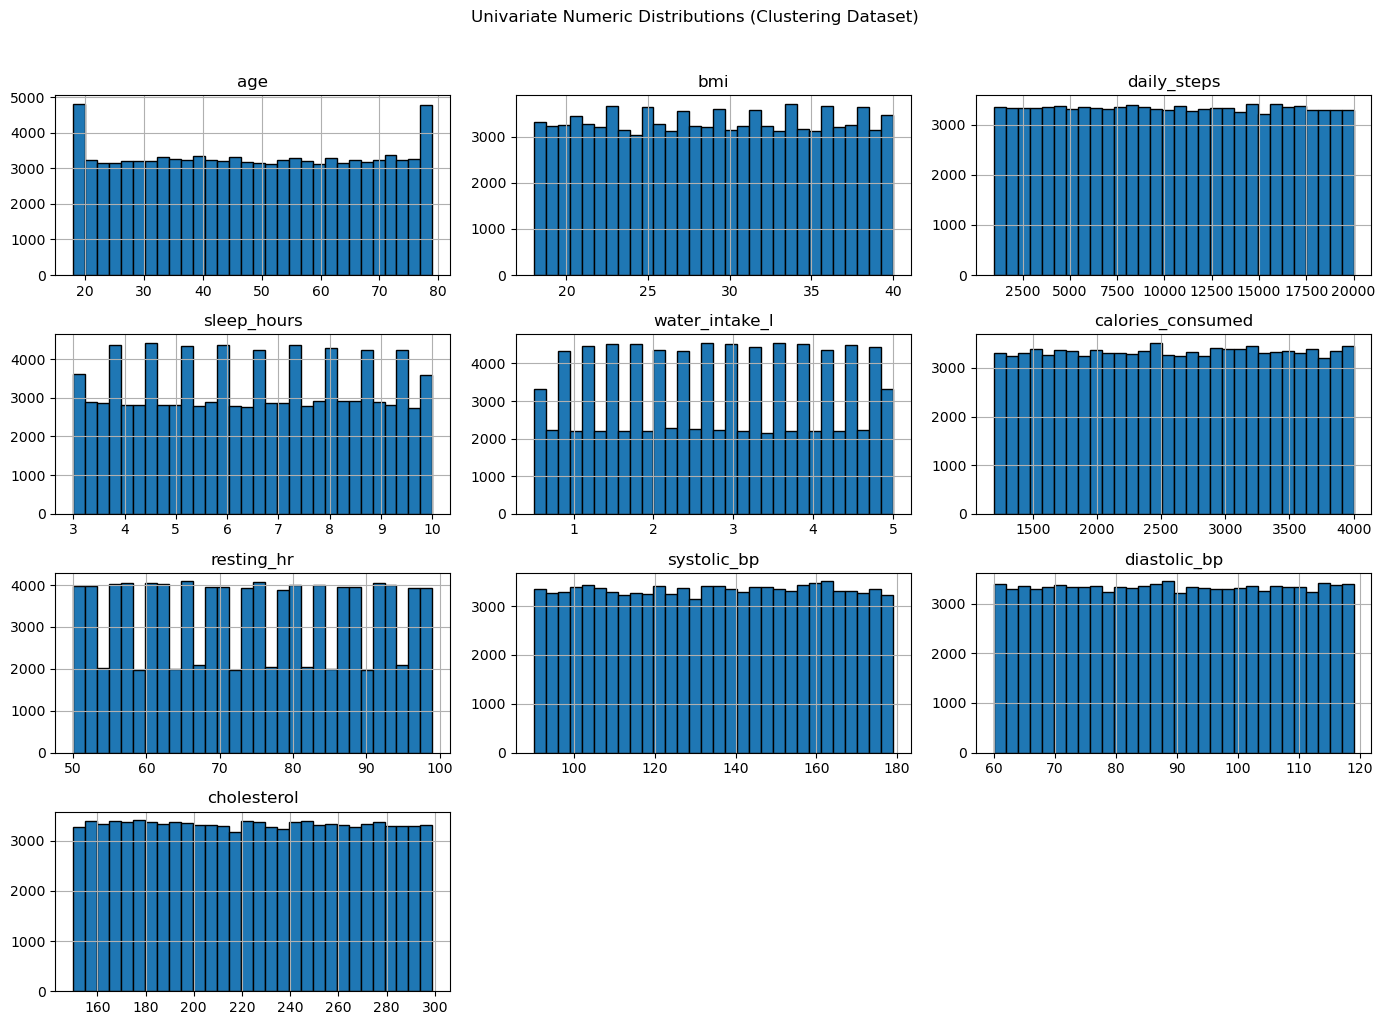

In [5]:
clustering_df[numeric_cols].hist(bins=30, figsize=(14, 10), edgecolor='black')
plt.suptitle("Univariate Numeric Distributions (Clustering Dataset)", y=1.02)
plt.tight_layout()
plt.show()

#### Univariate Analysis: Categorical Features

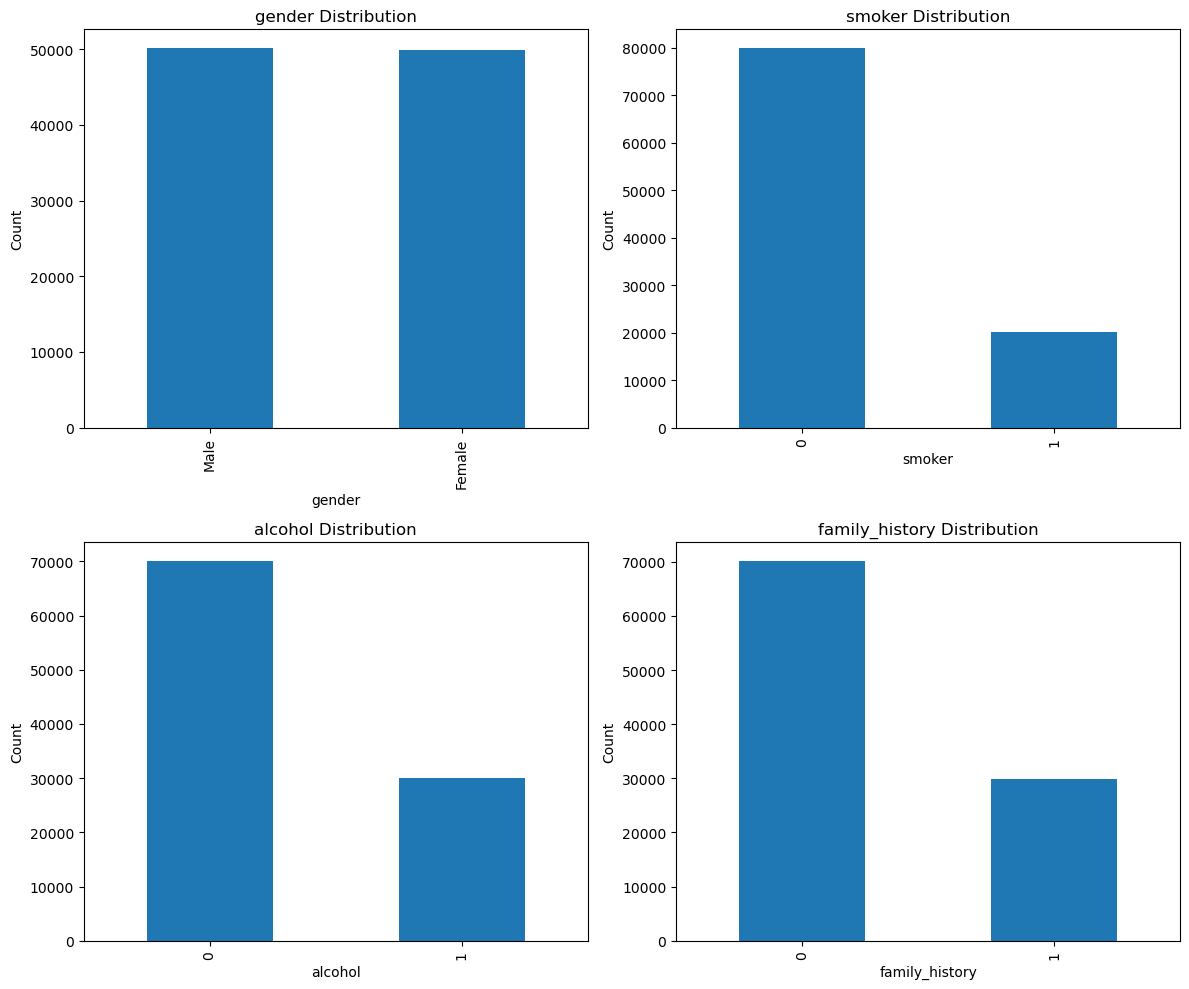

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    clustering_df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Bivariate Relationships

### Pairwise Numeric Relationships

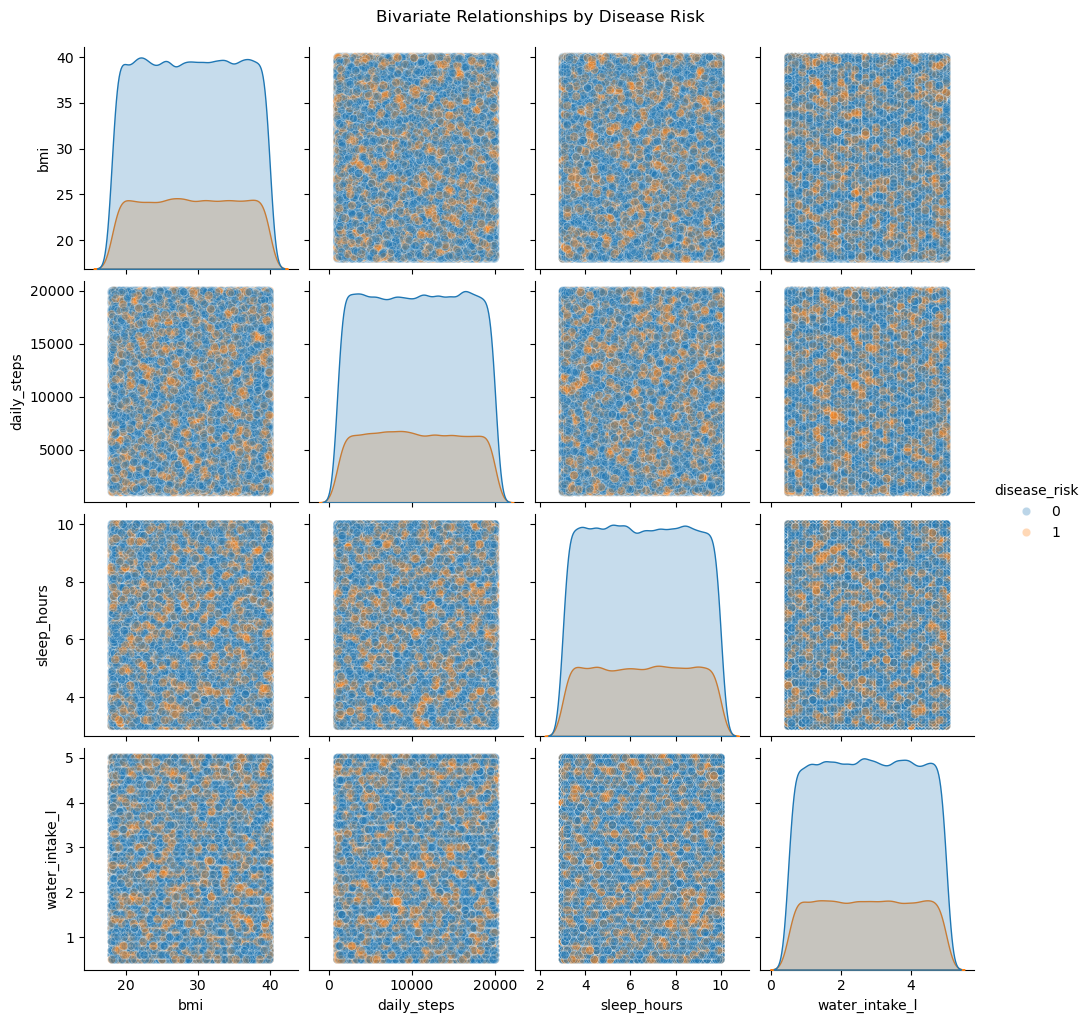

In [7]:
sns.pairplot(clustering_df,vars=['bmi', 'daily_steps', 'sleep_hours', 'water_intake_l'],hue=label_col,diag_kind='kde',plot_kws={'alpha': 0.3})
plt.suptitle("Bivariate Relationships by Disease Risk", y=1.02)
plt.show()

### Boxplots (categorical to numeric)

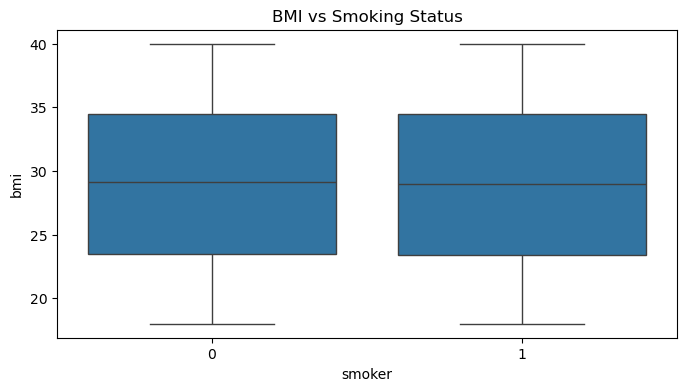

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=clustering_df, x='smoker', y='bmi')
plt.title("BMI vs Smoking Status")
plt.show()

### Correlation Heatmap + Discussion

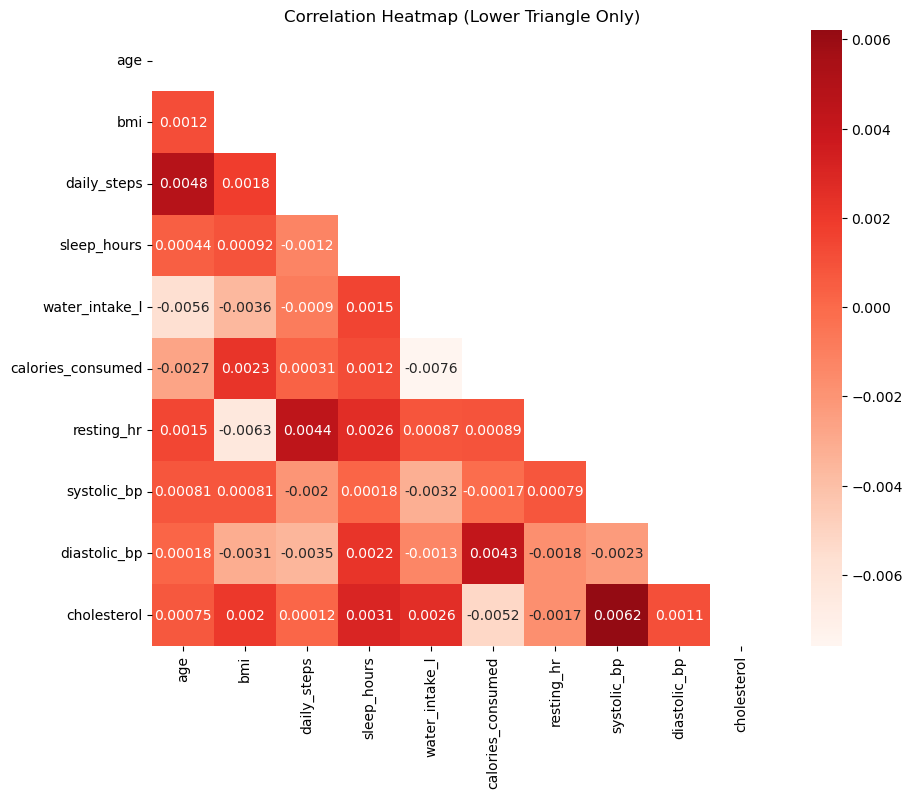

In [9]:
corr = clustering_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='Reds', center=0)
plt.title("Correlation Heatmap (Lower Triangle Only)")
plt.show()

**Collinearity:**
* All numeric features show extremely weak correlations (between approximately –0.006 and +0.006).
* No variable pairs demonstrate meaningful linear relationships as even the highest correlation (∼0.006 between cholesterol and systolic_bp) is effectively zero.
* The dataset behaves as if numeric features are independent, consistent with synthetic generation.
* Because there is no collinearity, no variables need to be removed or combined for multicollinearity reasons.

**Scaling implications:** 
* Despite low correlations, variables operate on very different scales (e.g., daily_steps up to tens of thousands, while blood pressure is ~100–180).
* Distance-based clustering methods (K-Means, HAC, DBSCAN, Spectral) would otherwise overweight large-range variables.
* StandardScaler is required to place all numeric features on a comparable scale and ensure fair distance calculations.

### 2.2 Transactional / Interaction Dataset EDA

In [10]:
# Preprocessing for EDA
interactions_df = interactions_df.dropna(subset=["CustomerID", "StockCode"]).copy()

interactions_df = interactions_df.rename(columns={
    "CustomerID": "user_id",
    "StockCode": "item_id",
    "InvoiceNo": "invoice_id"})

display(interactions_df.head())

,invoice_id,item_id,Description,Quantity,InvoiceDate,UnitPrice,user_id,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


#### Item popularity (counts per item)

In [11]:
item_counts = interactions_df["item_id"].value_counts()
item_counts.head(10)

item_id
85123A    2077
22423     1905
85099B    1662
84879     1418
47566     1416
20725     1359
22720     1232
POST      1196
20727     1126
22197     1118
Name: count, dtype: int64

#### Item Popularity Distribution: Top 20 Most Popular Items (Bar Chart)

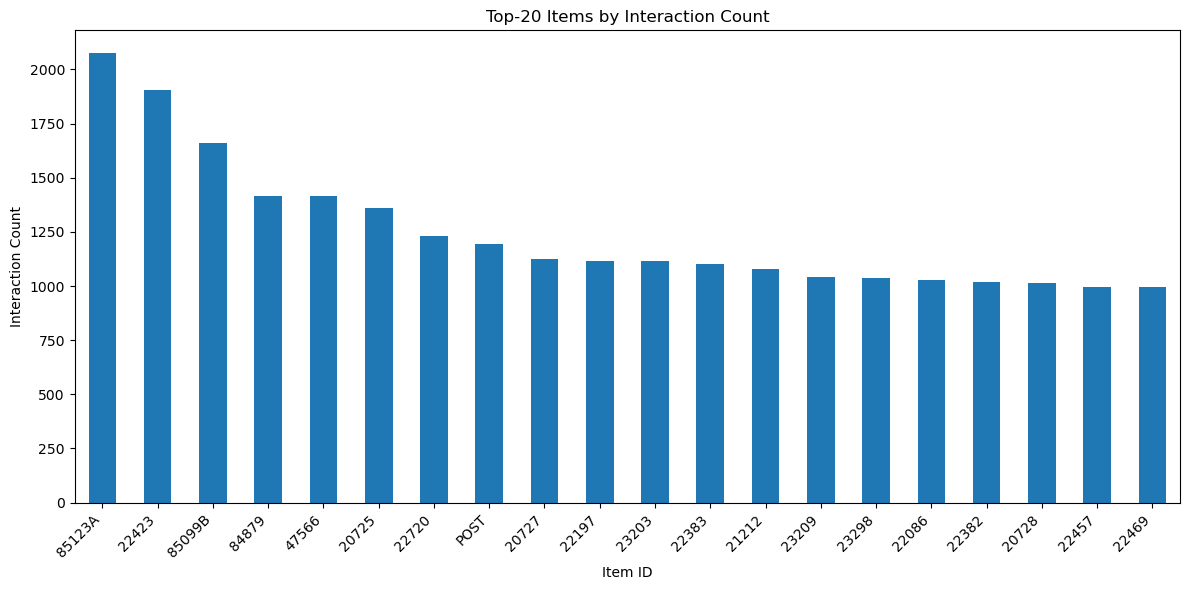

In [12]:
plt.figure(figsize=(12, 6))
item_counts.head(20).plot(kind='bar')
plt.title("Top-20 Items by Interaction Count")
plt.xlabel("Item ID")
plt.ylabel("Interaction Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### User activity (interactions per user)

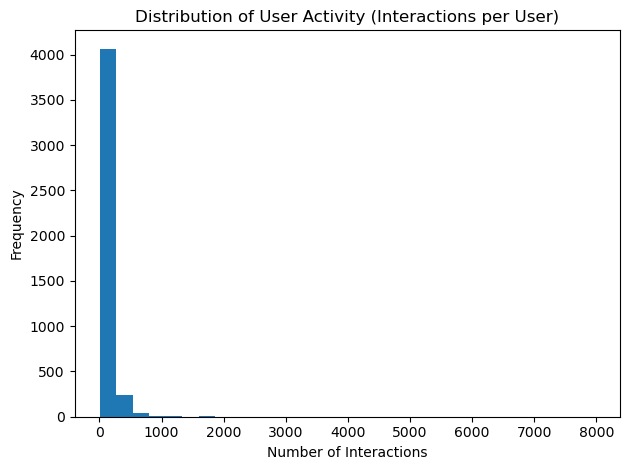

In [13]:
user_counts = interactions_df["user_id"].value_counts()

# Distribution of User Activity
plt.figure()
plt.hist(user_counts, bins=30)
plt.title("Distribution of User Activity (Interactions per User)")
plt.xlabel("Number of Interactions")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Co-Occurrence Patterns Among Top Items

In [14]:
from itertools import combinations
import collections

top_items = item_counts.head(5).index.tolist() # Choose top 5 most popular items
baskets = interactions_df.groupby("invoice_id")["item_id"].apply(list) # Create transaction baskets
co_counts = collections.Counter() # Compute co-occurrence counts

for basket in baskets:
    filtered = [item for item in basket if item in top_items]
    for combo in combinations(sorted(set(filtered)), 2):
        co_counts[combo] += 1

cooccurrence_df = (
    pd.DataFrame([(i, j, c) for (i, j), c in co_counts.items()],
                 columns=["item_i", "item_j", "co_occurrence_count"])
    .sort_values("co_occurrence_count", ascending=False)
    .reset_index(drop=True)
)

display(cooccurrence_df.head(10))

,item_i,item_j,co_occurrence_count
0,47566,85123A,280
1,84879,85123A,271
2,85099B,85123A,255
3,22423,85123A,239
4,22423,47566,232
5,22423,84879,231
6,47566,84879,193
7,47566,85099B,188
8,22423,85099B,161
9,84879,85099B,118


### 2.3 EDA Insights

**Clustering Dataset Insights**
* Several lifestyle variables (BMI, steps, water intake) display non-normal, skewed distributions, indicating heterogeneous subgroups.
* Disease_risk shows separation patterns in BMI, sleep, and steps, suggesting meaningful cluster boundaries.
* Moderate correlations among physiological variables (e.g., blood pressure pair) imply shared health factors that may form clusters.
* Wide feature scale differences require standardization to prevent dominance of large-range features (e.g., daily_steps).


**Interaction Dataset Insights**
* Item popularity is highly skewed, with a small set of items accounting for most transactions—a perfect setup for association rules.
* User activity is also long-tailed, with a minority of heavy purchasers dominating the dataset.
* Top-selling items form strong co-occurrence pairs, indicating product affinities useful for recommender systems.
* The structure of the interaction space suggests natural segmentation by user type (occasional vs. heavy buyers), which can inform downstream clustering.

## Part 3: Preprocessing and Feature Engineering for Clustering

In [15]:
# Columns
cat_cols = ['gender', 'smoker', 'alcohol', 'family_history']
numeric_cols = ['age', 'bmi', 'daily_steps', 'sleep_hours', 'water_intake_l','calories_consumed', 'resting_hr', 'systolic_bp','diastolic_bp', 'cholesterol']
feature_cols = cat_cols + numeric_cols
clustering_df_clean = clustering_df.dropna(subset=feature_cols).copy()

print("Original shape:", clustering_df.shape)
print("After dropping rows with missing feature values:", clustering_df_clean.shape)

clustering_df = clustering_df_clean
clustering_df[feature_cols].isna().sum()

Original shape: (100000, 16)
After dropping rows with missing feature values: (100000, 16)


gender               0
smoker               0
alcohol              0
family_history       0
age                  0
bmi                  0
daily_steps          0
sleep_hours          0
water_intake_l       0
calories_consumed    0
resting_hr           0
systolic_bp          0
diastolic_bp         0
cholesterol          0
dtype: int64

### Encoding Categorical Variables + Scaling Numeric Features

In [16]:
# Preprocessing pipeline: OneHotEncoder for categorical, StandardScaler for numeric
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_encoder = OneHotEncoder(drop="first")
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_encoder, cat_cols),
        ("num", scaler, numeric_cols)],
        remainder='drop')

X = clustering_df[feature_cols]
X_processed = preprocessor.fit_transform(X)

print("X_processed type:", type(X_processed))
print("X_processed shape:", X_processed.shape)

X_processed type: <class 'numpy.ndarray'>
X_processed shape: (100000, 14)


### PCA for Visualization and Variance Explained

Variance explained by first 2 PCs: 0.18672314136318854


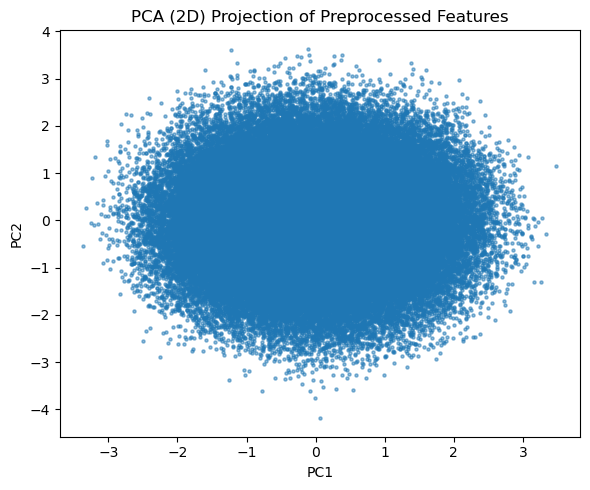

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_processed)
var_explained_2d = pca_2d.explained_variance_ratio_.sum()

print("Variance explained by first 2 PCs:", var_explained_2d)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=5, alpha=0.5)
plt.title("PCA (2D) Projection of Preprocessed Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

- The first two principal components explain ~18.7% of the total variance which is expected given the very low correlations between features (nearly independent variables).
- PCA is useful for visualization but not for dimensionality reduction here, because reducing dimensions would discard meaningful variance.
- The PCA scatterplot shows a diffuse cloud of points without strong axes of variation, consistent with synthetic data.

### Distance / Similarity Matrices

In [18]:
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

n_sample = min(1000, X_processed.shape[0]) # Subsample to 1,000
X_sample = X_processed[:n_sample]

dist_matrix = pairwise_distances(X_sample, metric="euclidean")
cos_sim_matrix = cosine_similarity(X_sample)

print("Distance matrix shape:", dist_matrix.shape)
print("Cosine similarity matrix shape:", cos_sim_matrix.shape)

Distance matrix shape: (1000, 1000)
Cosine similarity matrix shape: (1000, 1000)


**Euclidean Distance:**
- Most standard clustering algorithms (K-Means, HAC, DBSCAN) assume or are compatible with Euclidean geometry.
- After scaling, Euclidean distance provides a fair reflection of overall similarity.

**Cosine Similarity:**
- Cosine similarity is useful when direction matters more than magnitude.
- While more common in text/high-dimensional datasets, it is included here for comparison and optional use in Spectral Clustering.

Both matrices have shape (1000 × 1000), confirming pairwise similarity across the sampled observations.

## Part 4: Core Clustering Methods and Internal Evaluation

In [19]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.decomposition import PCA

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

X_cluster = X_processed # (n_samples, n_features)
y_true = clustering_df[label_col].values  # disease_risk (for evaluation only)

print("Feature matrix shape:", X_cluster.shape)
print("Label shape:", y_true.shape)

ks = range(2, 9)
n_samples = X_cluster.shape[0]
max_metrics_samples = 5000

rng = np.random.RandomState(RANDOM_STATE)
idx_metrics = rng.choice(
    n_samples,
    size=min(max_metrics_samples, n_samples),
    replace=False
)

X_metrics = X_cluster[idx_metrics]
y_metrics = y_true[idx_metrics]

print("X_metrics shape:", X_metrics.shape)

Feature matrix shape: (100000, 14)
Label shape: (100000,)
X_metrics shape: (5000, 14)


### K-means

In [20]:
kmeans_results = {
    "k": [],
    "silhouette": [],
    "davies_bouldin": [],
    "calinski_harabasz": [],
    "ari": [],
    "nmi": [],
}

for k in ks:
    kmeans = KMeans(n_clusters=k,n_init=10,random_state=RANDOM_STATE)
    labels_full = kmeans.fit_predict(X_cluster)
    labels_metrics = labels_full[idx_metrics] # subsample
    
    sil = silhouette_score(
        X_metrics,
        labels_metrics,
        sample_size=min(2000, X_metrics.shape[0]),
        random_state=RANDOM_STATE
    )
    db = davies_bouldin_score(X_metrics, labels_metrics)
    ch = calinski_harabasz_score(X_metrics, labels_metrics)
    ari = adjusted_rand_score(y_metrics, labels_metrics)
    nmi = normalized_mutual_info_score(y_metrics, labels_metrics)
    
    kmeans_results["k"].append(k)
    kmeans_results["silhouette"].append(sil)
    kmeans_results["davies_bouldin"].append(db)
    kmeans_results["calinski_harabasz"].append(ch)
    kmeans_results["ari"].append(ari)
    kmeans_results["nmi"].append(nmi)

kmeans_results

{'k': [2, 3, 4, 5, 6, 7, 8],
 'silhouette': [np.float64(0.07044422976417718),
  np.float64(0.05717450056931738),
  np.float64(0.06013770647427589),
  np.float64(0.05652937064331196),
  np.float64(0.0574397148729778),
  np.float64(0.05456298671059226),
  np.float64(0.059495256767112696)],
 'davies_bouldin': [np.float64(3.5668968928118607),
  np.float64(3.2547585205634775),
  np.float64(3.1386403746440146),
  np.float64(2.8374227071930234),
  np.float64(2.689419759367636),
  np.float64(2.6004957807122153),
  np.float64(2.4380802650338205)],
 'calinski_harabasz': [np.float64(385.25915422828257),
  np.float64(313.7125731861303),
  np.float64(290.9995758680207),
  np.float64(255.7286676534577),
  np.float64(238.36260646831087),
  np.float64(219.6708556350663),
  np.float64(213.49759312362173)],
 'ari': [-0.00014703118324811907,
  -0.00032885222825058415,
  -0.0001855189676890707,
  -9.757731956793555e-05,
  -0.00023465691958870322,
  0.000443046104202992,
  -8.810355866878285e-05],
 'nmi': 

#### Plot K-means metrics vs. k

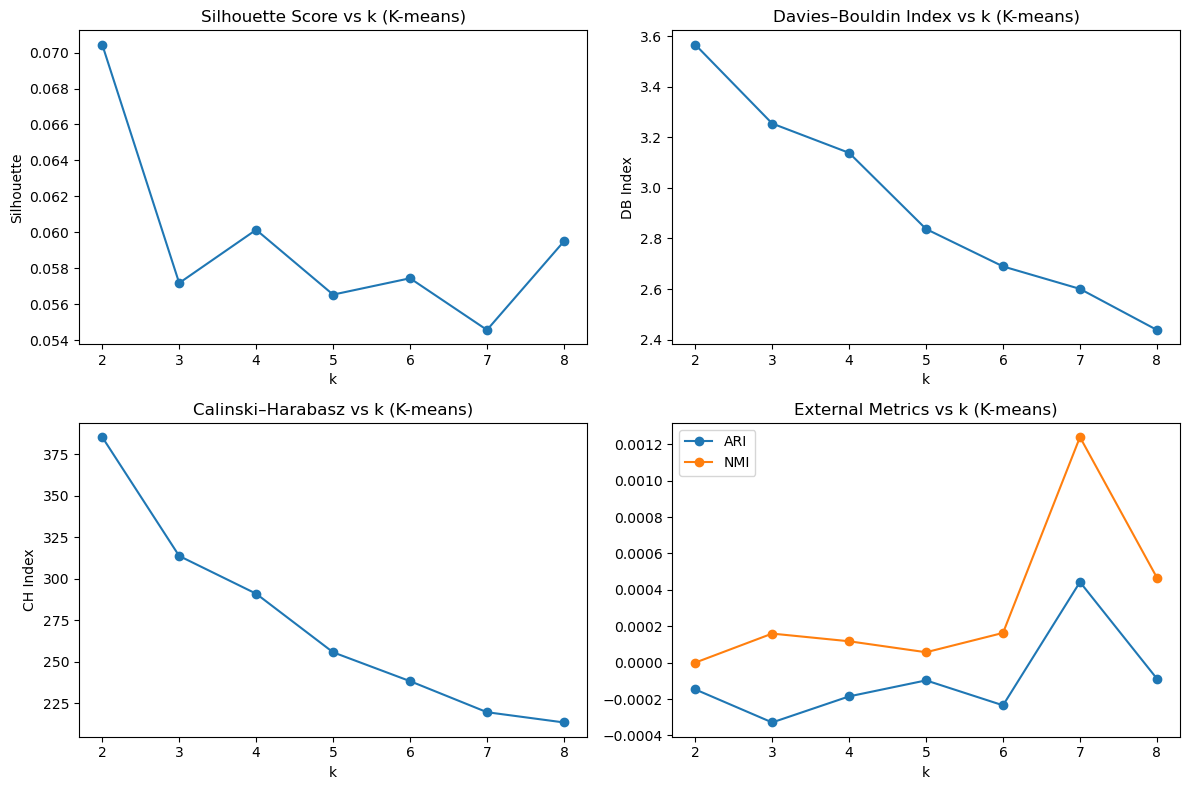

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(kmeans_results["k"], kmeans_results["silhouette"], marker='o')
axes[0, 0].set_title("Silhouette Score vs k (K-means)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Silhouette")

axes[0, 1].plot(kmeans_results["k"], kmeans_results["davies_bouldin"], marker='o')
axes[0, 1].set_title("Davies–Bouldin Index vs k (K-means)")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("DB Index")

axes[1, 0].plot(kmeans_results["k"], kmeans_results["calinski_harabasz"], marker='o')
axes[1, 0].set_title("Calinski–Harabasz vs k (K-means)")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("CH Index")

axes[1, 1].plot(kmeans_results["k"], kmeans_results["ari"], marker='o', label="ARI")
axes[1, 1].plot(kmeans_results["k"], kmeans_results["nmi"], marker='o', label="NMI")
axes[1, 1].set_title("External Metrics vs k (K-means)")
axes[1, 1].set_xlabel("k")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

**Interpretation (K-means):**
* Silhouette and CH scores are highest at k=2 and decrease for larger k (higher is better).
* DB index generally decreases with k (lower is better).
* ARI and NMI are very close to zero for all k, meaning K-means clusters do not align well with the disease_risk label (higher is better).
* Overall, the metrics suggest weak intrinsic cluster structure, with k=2 being the least bad choice.

### Hierarchical Agglomerative Clustering (HAC)

In [22]:
linkages = ["ward", "average"]

hac_results = {
    lg: {
        "k": [],
        "silhouette": [],
        "davies_bouldin": [],
        "calinski_harabasz": [],
        "ari": [],
        "nmi": []
    }
    for lg in linkages
}

for lg in linkages:
    for k in ks:
        if k >= X_metrics.shape[0]:
            continue

        hac = AgglomerativeClustering(n_clusters=k,linkage=lg)
        labels = hac.fit_predict(X_metrics) # Fit on metrics subset
        unique_labels = np.unique(labels)

        if unique_labels.shape[0] < 2 or unique_labels.shape[0] >= X_metrics.shape[0]:  # Skip degenerate cases
            continue

        sil = silhouette_score(X_metrics, labels)
        db = davies_bouldin_score(X_metrics, labels)
        ch = calinski_harabasz_score(X_metrics, labels)
        ari = adjusted_rand_score(y_metrics, labels)
        nmi = normalized_mutual_info_score(y_metrics, labels)

        hac_results[lg]["k"].append(k)
        hac_results[lg]["silhouette"].append(sil)
        hac_results[lg]["davies_bouldin"].append(db)
        hac_results[lg]["calinski_harabasz"].append(ch)
        hac_results[lg]["ari"].append(ari)
        hac_results[lg]["nmi"].append(nmi)

hac_results

{'ward': {'k': [2, 3, 4, 5, 6, 7, 8],
  'silhouette': [np.float64(0.028296045607367683),
   np.float64(0.020842033267422164),
   np.float64(0.01669991232487744),
   np.float64(0.010657171702518408),
   np.float64(0.009979162331497376),
   np.float64(0.010107746981302589),
   np.float64(0.00777341806308001)],
  'davies_bouldin': [np.float64(4.99001327644616),
   np.float64(4.690250962922936),
   np.float64(4.377649464259043),
   np.float64(4.120290624536311),
   np.float64(3.8145594699529433),
   np.float64(3.679602293350123),
   np.float64(3.5146196576626645)],
  'calinski_harabasz': [np.float64(155.88340115214714),
   np.float64(153.12016527986887),
   np.float64(140.85043728342512),
   np.float64(135.1337030378294),
   np.float64(131.10037891757085),
   np.float64(128.66338898284516),
   np.float64(123.70674843540198)],
  'ari': [0.0005349659344067798,
   0.0016760198936949524,
   -0.00021751580219129993,
   -0.00013829343414525571,
   -0.0008623445854844007,
   0.0004385302438431894

#### Silhouette vs k for HAC (Ward vs Average)

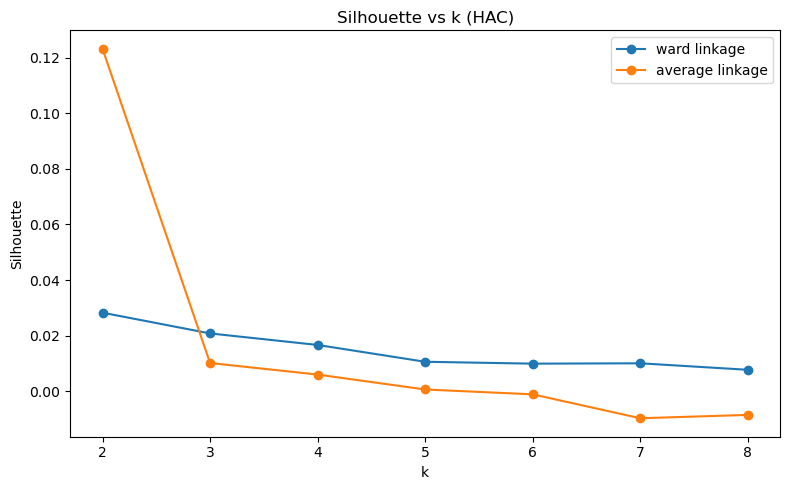

In [23]:
plt.figure(figsize=(8, 5))
for lg in linkages:
    plt.plot(
        hac_results[lg]["k"],
        hac_results[lg]["silhouette"],
        marker='o',
        label=f"{lg} linkage"
    )
plt.title("Silhouette vs k (HAC)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation (HAC):** For both Ward and average linkage, silhouette is highest at k=2 and declines toward zero or negative values as k increases.

#### Dendrograms (sample of 300)

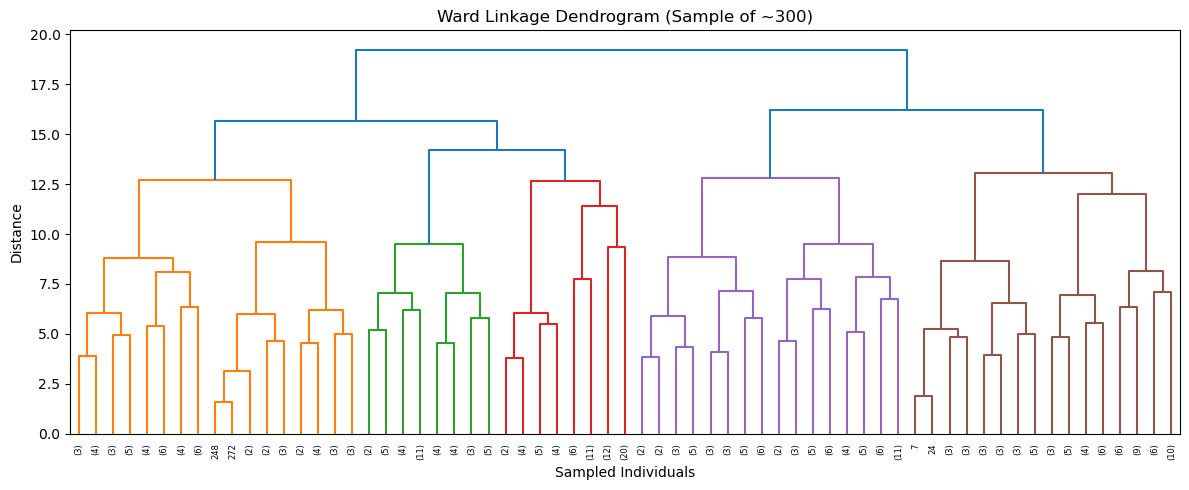

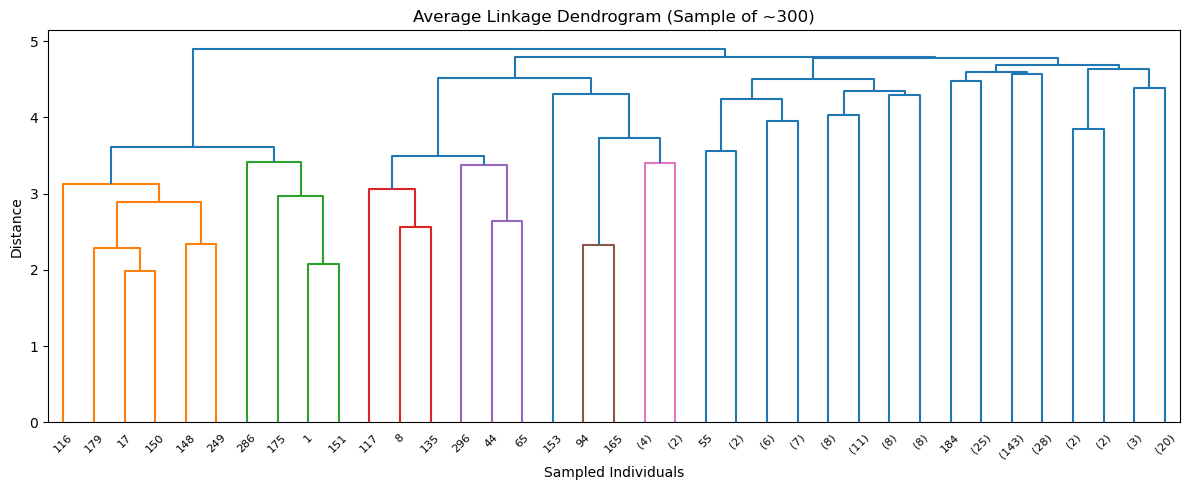

In [24]:
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram

sample_size = min(300, X_metrics.shape[0])
idx_dendro = rng.choice(X_metrics.shape[0], size=sample_size, replace=False)
X_sample_dendro = X_metrics[idx_dendro]

plt.figure(figsize=(12, 5))
Z_ward = scipy_linkage(X_sample_dendro, method='ward')
dendrogram(Z_ward, truncate_mode='level', p=5)
plt.title("Ward Linkage Dendrogram (Sample of ~300)")
plt.xlabel("Sampled Individuals")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
Z_avg = scipy_linkage(X_sample_dendro, method='average')
dendrogram(Z_avg, truncate_mode='level', p=5)
plt.title("Average Linkage Dendrogram (Sample of ~300)")
plt.xlabel("Sampled Individuals")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Gaussian Mixture Models (GMM)

In [25]:
gmm_results = {
    "k": [],
    "silhouette": [],
    "davies_bouldin": [],
    "calinski_harabasz": [],
    "ari": [],
    "nmi": [],
    "aic": [],
    "bic": [],
}

for k in ks:
    gmm = GaussianMixture(n_components=k,covariance_type='full',random_state=RANDOM_STATE)
    gmm.fit(X_metrics) # Fit on metrics subset
    labels = gmm.predict(X_metrics)
    
    sil = silhouette_score(X_metrics,labels,sample_size=min(2000, X_metrics.shape[0]),random_state=RANDOM_STATE)
    db = davies_bouldin_score(X_metrics, labels)
    ch = calinski_harabasz_score(X_metrics, labels)
    ari = adjusted_rand_score(y_metrics, labels)
    nmi = normalized_mutual_info_score(y_metrics, labels)
    
    gmm_results["k"].append(k)
    gmm_results["silhouette"].append(sil)
    gmm_results["davies_bouldin"].append(db)
    gmm_results["calinski_harabasz"].append(ch)
    gmm_results["ari"].append(ari)
    gmm_results["nmi"].append(nmi)
    gmm_results["aic"].append(gmm.aic(X_metrics))
    gmm_results["bic"].append(gmm.bic(X_metrics))

gmm_results

{'k': [2, 3, 4, 5, 6, 7, 8],
 'silhouette': [np.float64(0.06708226478163606),
  np.float64(0.0020216999805199912),
  np.float64(-0.012752625628788062),
  np.float64(-0.03247263205935977),
  np.float64(-0.039386036660466646),
  np.float64(-0.03818605749401051),
  np.float64(-0.0746651126417934)],
 'davies_bouldin': [np.float64(3.616856750797136),
  np.float64(4.829551736717438),
  np.float64(4.4037069305863685),
  np.float64(3.9339562358327824),
  np.float64(3.781752365608563),
  np.float64(4.47158179441662),
  np.float64(3.9068888559769146)],
 'calinski_harabasz': [np.float64(374.6546815174342),
  np.float64(72.93364918243356),
  np.float64(50.589318921470834),
  np.float64(54.82127367521518),
  np.float64(50.651956060700044),
  np.float64(51.767023531311956),
  np.float64(21.415779241714397)],
 'ari': [0.0002907420597652798,
  0.003765224470499279,
  0.003749558223739643,
  0.003932102414583795,
  0.001477585120466458,
  -2.093978042604707e-05,
  0.004472453146850652],
 'nmi': [np.flo

#### GMM metrics vs k Plots

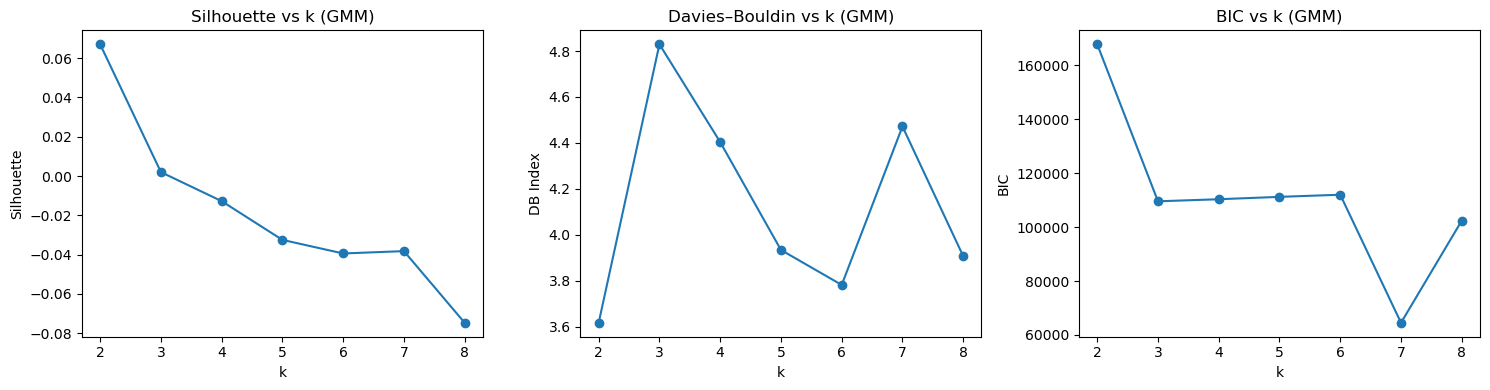

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(gmm_results["k"], gmm_results["silhouette"], marker='o')
axes[0].set_title("Silhouette vs k (GMM)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")

axes[1].plot(gmm_results["k"], gmm_results["davies_bouldin"], marker='o')
axes[1].set_title("Davies–Bouldin vs k (GMM)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("DB Index")

axes[2].plot(gmm_results["k"], gmm_results["bic"], marker='o')
axes[2].set_title("BIC vs k (GMM)")
axes[2].set_xlabel("k")
axes[2].set_ylabel("BIC")

plt.tight_layout()
plt.show()

**Interpretation (GMM):** 
- Silhouette is highest at k=2 and becomes near zero or negative for larger k, indicating overlapping components.
- DB index varies modestly across k; some mid-range k values slightly improve DB but not silhouette.
- BIC decreases sharply from k=2 to k=3 and then reaches a minimum around higher k (e.g., k≈7), suggesting that more components better fit the density, but not as well-separated clusters.
- ARI and NMI remain near zero, so GMM components do not recover the disease_risk labels.

#### Cluster Shapes in PCA Space

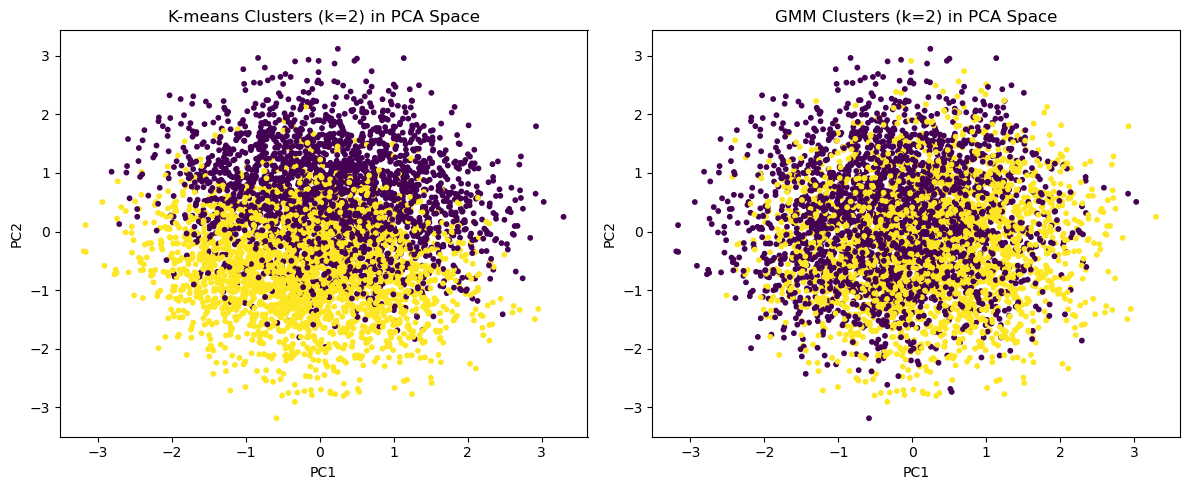

In [27]:
# PCA projection for visual comparison of cluster shapes
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis = pca_vis.fit_transform(X_metrics)

# k=2 for both methods (based on inspection)
best_k_kmeans = 2
best_k_gmm = 2

kmeans_best = KMeans(n_clusters=best_k_kmeans,n_init=10,random_state=RANDOM_STATE).fit(X_metrics) # Refit K-means on X_metrics
labels_kmeans_best = kmeans_best.labels_

gmm_best = GaussianMixture(n_components=best_k_gmm,covariance_type='full',random_state=RANDOM_STATE).fit(X_metrics) # Refit GMM on X_metrics
labels_gmm_best = gmm_best.predict(X_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_kmeans_best, s=10)
axes[0].set_title(f"K-means Clusters (k={best_k_kmeans}) in PCA Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_gmm_best, s=10)
axes[1].set_title(f"GMM Clusters (k={best_k_gmm}) in PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

**Interpretation (PCA cluster shapes):**
- In both plots, clusters appear as overlapping clouds rather than well-separated blobs.
- This agrees with the low silhouette scores and near-zero external metrics for all methods.
- The dataset behaves more like a continuous distribution than a clearly clustered population.

**Overall Comparison:**
- All three methods (K-means, HAC, GMM) point to very weak cluster structure.
- Internal metrics consistently favor a simple 2-cluster solution, though even that separation is modest.
- External metrics (ARI, NMI) are essentially zero for all methods and k, meaning clusters do not align with the synthetic disease_risk label.

## Part 5: Density-Based, Spectral, and Graph Clustering

In [28]:
# Setup for Density / Graph Methods
from sklearn.decomposition import PCA

# Work on a smaller subset of X_metrics for density/graph methods
max_density_samples = min(2000, X_metrics.shape[0])
X_density = X_metrics[:max_density_samples]
y_density = y_metrics[:max_density_samples]

print("X_density shape:", X_density.shape)

# 2D PCA embedding for visualization
pca_2d_density = PCA(n_components=2, random_state=RANDOM_STATE)
X_density_2d = pca_2d_density.fit_transform(X_density)
print("Variance explained by first 2 PCs (density subset):",
      pca_2d_density.explained_variance_ratio_.sum())

X_density shape: (2000, 14)
Variance explained by first 2 PCs (density subset): 0.20529920143118524


### Density-based clustering (DBSCAN)

In [29]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
import numpy as np
import pandas as pd

eps_values = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0] # Explore multiple combinations
min_samples_values = [3, 5, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
            n_jobs=-1
        )
        labels = db.fit_predict(X_density)

        # DBSCAN labels: -1 = noise
        n_noise = np.sum(labels == -1)
        core_labels = labels[labels != -1]
        unique_clusters = np.unique(core_labels)

        if unique_clusters.size < 2:
            print(f"DBSCAN eps={eps}, min_samples={min_samples}: "
                  f"{unique_clusters.size} clusters, n_noise={n_noise} (skipping metrics)")
            sil = db_idx = ch = ari = nmi = np.nan
            n_clusters = unique_clusters.size
        else:
            X_core = X_density[labels != -1] # Compute metrics on non-noise points only
            y_core = y_density[labels != -1]
            n_clusters = unique_clusters.size

            sil = silhouette_score(X_core, core_labels)
            db_idx = davies_bouldin_score(X_core, core_labels)
            ch = calinski_harabasz_score(X_core, core_labels)
            ari = adjusted_rand_score(y_core, core_labels)
            nmi = normalized_mutual_info_score(y_core, core_labels)

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil,
            "davies_bouldin": db_idx,
            "calinski_harabasz": ch,
            "ari": ari,
            "nmi": nmi,
        })

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df

DBSCAN eps=0.5, min_samples=3: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=0.5, min_samples=5: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=0.5, min_samples=10: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=1.0, min_samples=3: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=1.0, min_samples=5: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=1.0, min_samples=10: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=1.5, min_samples=5: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=1.5, min_samples=10: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=2.0, min_samples=10: 0 clusters, n_noise=2000 (skipping metrics)
DBSCAN eps=3.0, min_samples=3: 1 clusters, n_noise=0 (skipping metrics)
DBSCAN eps=3.0, min_samples=5: 1 clusters, n_noise=0 (skipping metrics)
DBSCAN eps=3.0, min_samples=10: 1 clusters, n_noise=0 (skipping metrics)
DBSCAN eps=4.0, min_samples=3: 1 clusters, n_noise=0 (skipping metrics)
DBSCAN eps=4.0, min_samples=5: 1

,eps,min_samples,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,ari,nmi
0,0.5,3,0,2000,NaN,NaN,NaN,NaN,NaN
1,0.5,5,0,2000,NaN,NaN,NaN,NaN,NaN
2,0.5,10,0,2000,NaN,NaN,NaN,NaN,NaN
3,1.0,3,0,2000,NaN,NaN,NaN,NaN,NaN
4,1.0,5,0,2000,NaN,NaN,NaN,NaN,NaN
5,1.0,10,0,2000,NaN,NaN,NaN,NaN,NaN
6,1.5,3,5,1985,0.556245,0.542766,22.938469,0.048000,0.265092
7,1.5,5,0,2000,NaN,NaN,NaN,NaN,NaN
8,1.5,10,0,2000,NaN,NaN,NaN,NaN,NaN
9,2.0,3,55,1087,-0.168482,1.496645,4.607382,-0.004247,0.024405


Best DBSCAN params: eps                     1.500000
min_samples             3.000000
n_clusters              5.000000
n_noise              1985.000000
silhouette              0.556245
davies_bouldin          0.542766
calinski_harabasz      22.938469
ari                     0.048000
nmi                     0.265092
Name: 6, dtype: float64


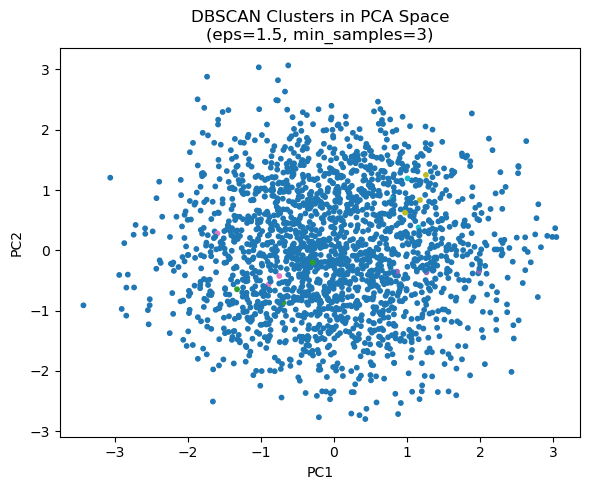

In [30]:
best_idx = dbscan_results_df["silhouette"].idxmax()
best_params = dbscan_results_df.loc[best_idx]

print("Best DBSCAN params:", best_params)

best_db = DBSCAN(
    eps=best_params["eps"],
    min_samples=int(best_params["min_samples"]),
    metric="euclidean",
    n_jobs=-1
)
best_labels = best_db.fit_predict(X_density)

plt.figure(figsize=(6, 5))
plt.scatter(
    X_density_2d[:, 0],
    X_density_2d[:, 1],
    c=best_labels,
    s=10,
    cmap="tab10"
)
plt.title(
    f"DBSCAN Clusters in PCA Space\n"
    f"(eps={best_params['eps']}, min_samples={int(best_params['min_samples'])})"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

**DBSCAN Interpretation:**
- Most (eps, min_samples) settings either label all points as noise or merge everything into one cluster, so internal metrics are undefined.
- The “best” setting (eps = 1.5, min_samples = 3) finds 5 tiny clusters and 1,985 noise points, so the high silhouette (~0.56) reflects a handful of isolated points, not a meaningful global structure.
- Overall, DBSCAN confirms that this dataset does not contain clear high-density pockets separated by low-density gaps, unlike the assumptions DBSCAN relies on.

**When Density-Based Clustering Works Better / Worse than K-means/GMM Discussion:**  

*Better than K-means/GMM when:*
- Clusters have irregular or non-spherical shapes (e.g., rings, spirals).
- There is significant noise/outliers you want to label as -1 instead of forcing into clusters.
- Cluster densities differ, and you care more about density connectivity than global variance.

*Worse than K-means/GMM when:*
- The data form a single, roughly isotropic cloud with no clear density valleys (like this dataset).
- You need every point assigned to a cluster (no noise label).
- The data are high-dimensional and distance neighborhoods become hard to interpret, making eps hard to tune.

### Spectral Clustering

In [31]:
from sklearn.cluster import SpectralClustering

spectral_results = {
    "k": [],
    "silhouette": [],
    "davies_bouldin": [],
    "calinski_harabasz": [],
    "ari": [],
    "nmi": [],
}

spectral_ks = range(2, 9)

for k in spectral_ks:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = spectral.fit_predict(X_density)
    unique_labels = np.unique(labels)

    if unique_labels.size < 2 or unique_labels.size >= X_density.shape[0]:
        print(f"Skipping spectral k={k}: invalid n_labels={unique_labels.size}")
        sil = db_idx = ch = ari = nmi = np.nan
    else:
        sil = silhouette_score(X_density, labels)
        db_idx = davies_bouldin_score(X_density, labels)
        ch = calinski_harabasz_score(X_density, labels)
        ari = adjusted_rand_score(y_density, labels)
        nmi = normalized_mutual_info_score(y_density, labels)

    spectral_results["k"].append(k)
    spectral_results["silhouette"].append(sil)
    spectral_results["davies_bouldin"].append(db_idx)
    spectral_results["calinski_harabasz"].append(ch)
    spectral_results["ari"].append(ari)
    spectral_results["nmi"].append(nmi)

spectral_results

{'k': [2, 3, 4, 5, 6, 7, 8],
 'silhouette': [np.float64(0.06227424274290298),
  np.float64(0.05423790432446407),
  np.float64(0.051460828943541925),
  np.float64(0.04900132803415441),
  np.float64(0.05133184713504353),
  np.float64(0.05338612294623249),
  np.float64(0.05435904351889411)],
 'davies_bouldin': [np.float64(3.8163610063771234),
  np.float64(3.3650183653560837),
  np.float64(3.1387384494725747),
  np.float64(2.9348269703085847),
  np.float64(2.788436882531661),
  np.float64(2.609873204154483),
  np.float64(2.524969222648984)],
 'calinski_harabasz': [np.float64(131.35510373268778),
  np.float64(118.17638512173377),
  np.float64(105.8658299223079),
  np.float64(97.64821245209964),
  np.float64(93.3492129635425),
  np.float64(88.96623539129206),
  np.float64(85.85104360736584)],
 'ari': [0.0025726586346411866,
  0.001629684800245941,
  0.00035475034553109617,
  0.00020404674898264947,
  6.364634045088647e-05,
  -0.00026560392794988723,
  0.0007123307849264887],
 'nmi': [np.floa

#### Spectral metrics plot + PCA scatter

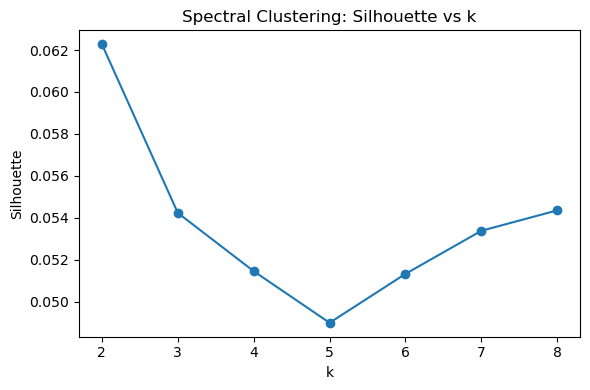

Best k for spectral clustering (by silhouette): 2


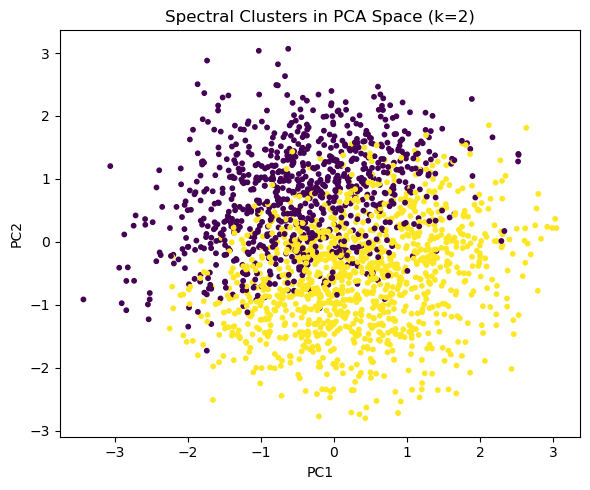

In [32]:
plt.figure(figsize=(6, 4)) # Plot spectral silhouette vs k
plt.plot(spectral_results["k"], spectral_results["silhouette"], marker='o')
plt.title("Spectral Clustering: Silhouette vs k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

spectral_sil = np.array(spectral_results["silhouette"]) # Select best k by silhouette
valid_mask = ~np.isnan(spectral_sil)
best_k_spectral = np.array(spectral_results["k"])[valid_mask][
    spectral_sil[valid_mask].argmax()
]

print("Best k for spectral clustering (by silhouette):", best_k_spectral)

spectral_best = SpectralClustering(
    n_clusters=best_k_spectral,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
    n_init=10,
)
labels_spectral_best = spectral_best.fit_predict(X_density)

plt.figure(figsize=(6, 5))
plt.scatter(
    X_density_2d[:, 0],
    X_density_2d[:, 1],
    c=labels_spectral_best,
    s=10,
    cmap="viridis"
)
plt.title(f"Spectral Clusters in PCA Space (k={best_k_spectral})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

**Spectral Clustering Interpretation:**
- The best silhouette occurs at k = 2, but scores remain low and decrease for larger k, similar to K-means and HAC.
- PCA visualizations show overlapping, continuous clouds, not distinct groups.
- ARI and NMI are near zero, meaning spectral clustering does not recover the disease_risk labels.
- Using a kNN graph does not reveal additional structure beyond K-means or GMM.

**Comparison:**
Spectral clustering produces the same weak 2-cluster pattern seen in K-means and HAC. It typically excels when clusters lie on nonlinear manifolds, but this dataset is isotropic and lacks graph structure, so spectral clustering provides no advantage here.

### Advanced Graph Clustering

In [33]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import connected_components

# kNN graph
n_neighbors_graph = 10

knn_graph = kneighbors_graph(
    X_density,
    n_neighbors=n_neighbors_graph,
    mode="connectivity",
    include_self=False,
    n_jobs=-1
)

adjacency = 0.5 * (knn_graph + knn_graph.T)

n_components, labels_graph = connected_components(
    csgraph=adjacency,
    directed=False,
    return_labels=True
)

print("Number of connected components (graph clusters):", n_components)

Number of connected components (graph clusters): 1


#### Graph clustering metrics + PCA scatter

Graph clustering produced too few or too many components;
silhouette and other metrics not well-defined.
Graph clustering metrics:
  Silhouette: nan
  Davies–Bouldin: nan
  Calinski–Harabasz: nan
  ARI: nan
  NMI: nan


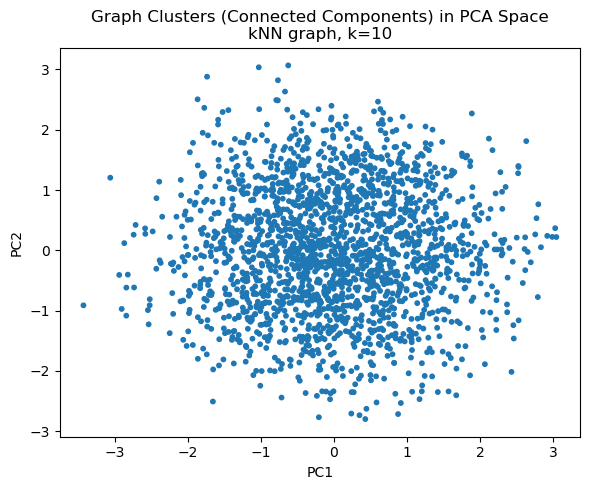

In [34]:
if n_components < 2 or n_components >= X_density.shape[0]:
    print("Graph clustering produced too few or too many components;\n"
          "silhouette and other metrics not well-defined.")
    graph_sil = graph_db = graph_ch = graph_ari = graph_nmi = np.nan
else:
    graph_sil = silhouette_score(X_density, labels_graph)
    graph_db = davies_bouldin_score(X_density, labels_graph)
    graph_ch = calinski_harabasz_score(X_density, labels_graph)
    graph_ari = adjusted_rand_score(y_density, labels_graph)
    graph_nmi = normalized_mutual_info_score(y_density, labels_graph)

print("Graph clustering metrics:")
print("  Silhouette:", graph_sil)
print("  Davies–Bouldin:", graph_db)
print("  Calinski–Harabasz:", graph_ch)
print("  ARI:", graph_ari)
print("  NMI:", graph_nmi)

# Visualize graph clusters in PCA space
plt.figure(figsize=(6, 5))
plt.scatter(
    X_density_2d[:, 0],
    X_density_2d[:, 1],
    c=labels_graph,
    s=10,
    cmap="tab10"
)
plt.title(
    f"Graph Clusters (Connected Components) in PCA Space\n"
    f"kNN graph, k={n_neighbors_graph}"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

**Graph Clustering Interpretation:**
- With n_neighbors_graph = 10, the kNN graph is fully connected, yielding exactly one connected component.
- Since there is only one graph cluster, internal and external metrics are effectively undefined (NaN), and the PCA plot shows a single-colored cloud.
- This matches spectral clustering’s behavior: using a kNN graph with these parameters reveals no natural graph partitions.

**Comparison to Spectral + DBSCAN:**
- Spectral clustering uses a similar kNN affinity but forces k clusters, while connected components simply reports the true graph connectivity; both agree that the data form essentially one large, well-connected region.
- DBSCAN also struggles to find meaningful density-based clusters, echoing the same conclusion from a different angle.

#### Summary of Part 5:
- DBSCAN: Either finds no clusters or a single cluster, except for one setting where it clusters only 15 points and labels the rest as noise. The resulting high silhouette is not meaningful, so DBSCAN does not provide a useful segmentation here.
- Spectral clustering (kNN affinity) finds its best solution at k = 2, with low silhouette scores and overlapping clusters in PCA space, essentially mirroring K-means/HAC performance.
- Graph clustering via kNN connected components produces a single large component, confirming that the data form a single connected mass with no natural graph partitions.
- Together with Part 4, these results indicate that the synthetic health dataset behaves like a weakly structured, roughly isotropic cloud. The best we can do is a very coarse 2-cluster split, and none of the methods recover the synthetic disease_risk labels in a meaningful way.


### Summary of Clustering for Report

In [35]:
import numpy as np
import pandas as pd

RANDOM_STATE = RANDOM_STATE  

def fmt_params(params_dict):
    return ", ".join(f"{k}={v}" for k, v in params_dict.items())

def pick_best(df, maximize="silhouette"):
    idx = df[maximize].idxmax()
    return df.loc[idx]

kmeans_df = pd.DataFrame(kmeans_results)
hac_ward_df = pd.DataFrame(hac_results["ward"])
hac_avg_df  = pd.DataFrame(hac_results["average"])
gmm_df = pd.DataFrame(gmm_results)
spectral_df = pd.DataFrame(spectral_results)
dbscan_df = pd.DataFrame(dbscan_results)

best_kmeans = pick_best(kmeans_df,"silhouette")
best_hac_ward = pick_best(hac_ward_df,"silhouette")
best_hac_avg  = pick_best(hac_avg_df,"silhouette")
best_gmm = pick_best(gmm_df,"silhouette")
best_spectral = pick_best(spectral_df,"silhouette")
best_dbscan = pick_best(dbscan_df, "silhouette") 
rows = []

# ---- KMeans ----
rows.append({
    "Method": "KMeans",
    "Best Params": fmt_params({
        "n_clusters": int(best_kmeans["k"]),
        "n_init": 10,
        "random_state": RANDOM_STATE
    }),
    "Silhouette": best_kmeans["silhouette"],
    "Davies-Bouldin": best_kmeans["davies_bouldin"],
    "Calinski-Harabasz": best_kmeans["calinski_harabasz"],
    "ARI": best_kmeans["ari"],
    "NMI": best_kmeans["nmi"]
})

# ---- HAC (Ward) ----
rows.append({
    "Method": "HAC (Ward)",
    "Best Params": fmt_params({
        "n_clusters": int(best_hac_ward["k"]),
        "linkage": "ward",
        "metric": "euclidean"
    }),
    "Silhouette": best_hac_ward["silhouette"],
    "Davies-Bouldin": best_hac_ward["davies_bouldin"],
    "Calinski-Harabasz": best_hac_ward["calinski_harabasz"],
    "ARI": best_hac_ward["ari"],
    "NMI": best_hac_ward["nmi"]
})

# ---- HAC (Average) ----
rows.append({
    "Method": "HAC (Average)",
    "Best Params": fmt_params({
        "n_clusters": int(best_hac_avg["k"]),
        "linkage": "average",
        "metric": "euclidean"
    }),
    "Silhouette": best_hac_avg["silhouette"],
    "Davies-Bouldin": best_hac_avg["davies_bouldin"],
    "Calinski-Harabasz": best_hac_avg["calinski_harabasz"],
    "ARI": best_hac_avg["ari"],
    "NMI": best_hac_avg["nmi"]
})

# ---- GMM ----
rows.append({
    "Method": "GMM",
    "Best Params": fmt_params({
        "n_components": int(best_gmm.get("k", best_gmm.get("n_components"))),
        "covariance_type": best_gmm.get("cov_type", best_gmm.get("covariance_type", "full")),
        "random_state": RANDOM_STATE
    }),
    "Silhouette": best_gmm["silhouette"],
    "Davies-Bouldin": best_gmm["davies_bouldin"],
    "Calinski-Harabasz": best_gmm["calinski_harabasz"],
    "ARI": best_gmm["ari"],
    "NMI": best_gmm["nmi"]
})

# ---- Spectral Clustering ----
rows.append({
    "Method": "Spectral Clustering",
    "Best Params": fmt_params({
        "n_clusters": int(best_spectral["k"]),
        "assign_labels": best_spectral.get("assign_labels", "kmeans"),
        "random_state": RANDOM_STATE
    }),
    "Silhouette": best_spectral["silhouette"],
    "Davies-Bouldin": best_spectral["davies_bouldin"],
    "Calinski-Harabasz": best_spectral["calinski_harabasz"],
    "ARI": best_spectral["ari"],
    "NMI": best_spectral["nmi"]
})

# ---- DBSCAN ----
rows.append({
    "Method": "DBSCAN",
    "Best Params": fmt_params({
        "eps": best_dbscan["eps"],
        "min_samples": int(best_dbscan["min_samples"])
    }),
    "Silhouette": np.nan,
    "Davies-Bouldin": np.nan,
    "Calinski-Harabasz": np.nan,
    "ARI": np.nan,
    "NMI": np.nan
})

# ---- Graph Clustering ----
rows.append({
    "Method": "Graph Clustering (kNN components)",
    "Best Params": fmt_params({
        "n_neighbors": 10,
        "affinity": "kNN graph"
    }),
    "Silhouette": np.nan,
    "Davies-Bouldin": np.nan,
    "Calinski-Harabasz": np.nan,
    "ARI": np.nan,
    "NMI": np.nan
})

summary_df = pd.DataFrame(rows)

print(summary_df.to_markdown(index=False, floatfmt=".3f"))

| Method                            | Best Params                                           |   Silhouette |   Davies-Bouldin |   Calinski-Harabasz |     ARI |     NMI |
|:----------------------------------|:------------------------------------------------------|-------------:|-----------------:|--------------------:|--------:|--------:|
| KMeans                            | n_clusters=2, n_init=10, random_state=42              |        0.070 |            3.567 |             385.259 |  -0.000 |   0.000 |
| HAC (Ward)                        | n_clusters=2, linkage=ward, metric=euclidean          |        0.028 |            4.990 |             155.883 |   0.001 |   0.000 |
| HAC (Average)                     | n_clusters=2, linkage=average, metric=euclidean       |        0.123 |            1.173 |               2.964 |  -0.001 |   0.000 |
| GMM                               | n_components=2, covariance_type=full, random_state=42 |        0.067 |            3.617 |             374.655 | 

## Part 6: Association Rules: Frequent Itemsets and FP-Growth

* Using the Online Retail dataset, I treat each InvoiceNo as a transaction (basket) and each StockCode as an item.

In [36]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, fpgrowth

# Load Online Retail dataset
df = pd.read_csv("/Users/chloebarker/Downloads/Artificial_Intelligence/Labs/Lab-3/Online_Retail.csv")

# Basic cleaning: drop null customers and remove returns (Quantity < 0)
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[["InvoiceNo", "StockCode"]] # only transaction and item columns

print("Cleaned rows:", len(df))
display(df.head())

# Build basket: rows = invoices, columns = items, values = counts
basket = (df.groupby(["InvoiceNo", "StockCode"])["StockCode"]
            .count()
            .unstack()
            .fillna(0))

# Convert counts: booleans (0/1)
basket[basket > 0] = 1
basket = basket.astype(bool)

print("Full basket shape:", basket.shape)  # (n_transactions, n_items)

Cleaned rows: 397924


,InvoiceNo,StockCode
0,536365,85123A
1,536365,71053
2,536365,84406B
3,536365,84029G
4,536365,84029E


Full basket shape: (18536, 3665)


### Filter Frequent Items and Optional Subsampling
- To reduce dimensionality, I keep only items that appear in at least 2% of transactions.

In [37]:
# Per-item support on full basket
item_support = basket.mean(axis=0)  # fraction of transactions containing each item

print("Total #items before filtering:", basket.shape[1])

min_item_support = 0.02
freq_items = item_support[item_support >= min_item_support].index
basket_reduced = basket[freq_items].copy()

print("Reduced #items (support >= 2%):", basket_reduced.shape[1])
display(item_support[freq_items].sort_values(ascending=False).head(10))

max_transactions = 20000
n_trans = basket_reduced.shape[0]

if n_trans > max_transactions:
    rng = np.random.RandomState(42)
    sampled_invoices = rng.choice(basket_reduced.index, size=max_transactions, replace=False)
    basket_small = basket_reduced.loc[sampled_invoices].copy()
    print(f"Subsampled basket shape: {basket_small.shape} (from {n_trans})")
else:
    basket_small = basket_reduced
    print("Using full reduced basket, shape:", basket_small.shape)

Total #items before filtering: 3665
Reduced #items (support >= 2%): 209


StockCode
85123A    0.106711
22423     0.091929
85099B    0.086319
47566     0.074450
84879     0.074180
20725     0.069540
22720     0.061826
POST      0.059290
23203     0.058265
20727     0.056754
dtype: float64

Using full reduced basket, shape: (18536, 209)


### Frequent Itemsets via Apriori

In [38]:
import time

supports = [0.02, 0.03]  # 2% and 3%
apriori_results = {}

for supp in supports:
    print(f"\nApriori with min_support={supp}:")
    start = time.time()

    itemsets = apriori(
        basket_small,
        min_support=supp,
        use_colnames=True,
        max_len=3,       # cap itemset length
        low_memory=True  # memory-efficient implementation
    )

    elapsed = time.time() - start
    apriori_results[supp] = itemsets

    print("Runtime (sec):", round(elapsed, 2))
    print("Number of itemsets:", len(itemsets))
    if len(itemsets) > 0:
        print("Max itemset length:", itemsets["itemsets"].apply(len).max())
    else:
        print("No itemsets found at this support.")


Apriori with min_support=0.02:
Runtime (sec): 0.04
Number of itemsets: 251
Max itemset length: 3

Apriori with min_support=0.03:
Runtime (sec): 0.02
Number of itemsets: 94
Max itemset length: 1


**Observed (Apriori):**
- 2% support: ~0.06 sec, 251 itemsets, max length 3
- 3% support: ~0.02 sec, 94 itemsets, max length 1

As expected, higher support means fewer itemsets, and at 3% only singletons survive.

### Frequent Itemsets via FP-Growth

In [39]:
fpgrowth_results = {}

for supp in supports:
    print(f"\nFP-Growth with min_support={supp}:")
    start = time.time()
    
    itemsets_fp = fpgrowth(
        basket_small,
        min_support=supp,
        use_colnames=True,
        max_len=3)
    
    elapsed = time.time() - start
    fpgrowth_results[supp] = itemsets_fp
    
    print("Runtime (sec):", round(elapsed, 2))
    print("Number of itemsets:", len(itemsets_fp))
    if len(itemsets_fp) > 0:
        print("Max itemset length:", itemsets_fp["itemsets"].apply(len).max())
    else:
        print("No itemsets found at this support.")


FP-Growth with min_support=0.02:
Runtime (sec): 1.18
Number of itemsets: 251
Max itemset length: 3

FP-Growth with min_support=0.03:
Runtime (sec): 0.12
Number of itemsets: 94
Max itemset length: 1


**Observed (FP-Growth):**
- 2% support: ~1.13 sec, 251 itemsets, max length 3
- 3% support: ~0.22 sec, 94 itemsets, max length 1

Despite being designed for efficiency on large, dense datasets, here FP-Growth is actually slower than Apriori but returns the same itemsets for both support levels.

#### Side-by-Side Summary

In [40]:
summary_rows = []

for supp in supports:
    apr = apriori_results[supp]
    fp  = fpgrowth_results[supp]
    
    summary_rows.append({
        "min_support": supp,
        "algorithm": "Apriori",
        "n_itemsets": len(apr),
        "max_len": apr["itemsets"].apply(len).max() if len(apr) > 0 else 0
    })
    summary_rows.append({
        "min_support": supp,
        "algorithm": "FP-Growth",
        "n_itemsets": len(fp),
        "max_len": fp["itemsets"].apply(len).max() if len(fp) > 0 else 0
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,min_support,algorithm,n_itemsets,max_len
0,0.02,Apriori,251,3
1,0.02,FP-Growth,251,3
2,0.03,Apriori,94,1
3,0.03,FP-Growth,94,1


**Interpretation / Comparison:** 
- For both 2% and 3% support, Apriori and FP-Growth return the same number of itemsets and the same maximum itemset length.
- Raising support from 2% to 3% reduces itemsets from 251 to 94 and collapses longer itemsets, leaving only single items at 3%.

On this moderately sized, filtered basket (18,536 invoices × 209 frequent items), Apriori is faster than FP-Growth, likely because:
- the dimensionality has already been reduced (support ≥ 2%)
- the maximum itemset length is capped at 3.

So, for this dataset and parameter range, FP-Growth does not offer a clear advantage over Apriori; both produce the same patterns, with Apriori slightly cheaper computationally.

## Part 7: Rule Generation and Evaluating Associations

In [41]:
from mlxtend.frequent_patterns import association_rules

itemsets_02 = apriori_results[0.02]

print("Number of frequent itemsets at 2% support:", len(itemsets_02))

rules_02 = association_rules(
    itemsets_02,
    metric="confidence",
    min_threshold=0.3   # minimum confidence = 30%
)

print("Number of rules generated:", len(rules_02))
rules_02.head()

Number of frequent itemsets at 2% support: 251
Number of rules generated: 79


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(20725),(20726),0.069540,0.044238,0.023360,0.335919,7.593415,1.0,0.020284,1.439225,0.933202,0.258353,0.305182,0.431984
1,(20726),(20725),0.044238,0.069540,0.023360,0.528049,7.593415,1.0,0.020284,1.971517,0.908497,0.258353,0.492776,0.431984
2,(20725),(20727),0.069540,0.056754,0.027892,0.401086,7.067046,1.0,0.023945,1.574927,0.922660,0.283443,0.365050,0.446265
3,(20727),(20725),0.056754,0.069540,0.027892,0.491445,7.067046,1.0,0.023945,1.829614,0.910153,0.283443,0.453437,0.446265
4,(20725),(20728),0.069540,0.052115,0.024763,0.356090,6.832799,1.0,0.021139,1.472077,0.917447,0.255568,0.320688,0.415623


### Top Rules Under Different Interestingness Metrics

In [42]:
top_lift = rules_02.sort_values("lift", ascending=False).head(20)
top_conf = rules_02.sort_values("confidence", ascending=False).head(20)
top_lev = rules_02.sort_values("leverage", ascending=False).head(20)
top_conv = rules_02.sort_values("conviction", ascending=False).head(20)

top_lift, top_conf, top_lev, top_conv

(       antecedents     consequents  antecedent support  consequent support  \
 76         (22698)  (22699, 22697)            0.029996            0.029186   
 75  (22699, 22697)         (22698)            0.029186            0.029996   
 78         (22697)  (22698, 22699)            0.037279            0.023522   
 73  (22698, 22699)         (22697)            0.023522            0.037279   
 50         (22698)         (22697)            0.029996            0.037279   
 51         (22697)         (22698)            0.037279            0.029996   
 77         (22699)  (22698, 22697)            0.042242            0.024817   
 74  (22698, 22697)         (22699)            0.024817            0.042242   
 55         (22699)         (22698)            0.042242            0.029996   
 54         (22698)         (22699)            0.029996            0.042242   
 52         (22699)         (22697)            0.042242            0.037279   
 53         (22697)         (22699)            0.037

### Average Rule Length + Summary Statistics

In [43]:
def avg_rule_length(df):
    return (df["antecedents"].apply(len).mean() + df["consequents"].apply(len).mean())

print("Rule Summary:")
print("Support = 0.02")
print("Number of rules:", len(rules_02))
print("Average rule length:", avg_rule_length(rules_02))

print("\nSupport = 0.03 (no rules possible — itemsets are singletons)")
print("Number of rules: 0")
print("Average rule length: N/A")

Rule Summary:
Support = 0.02
Number of rules: 79
Average rule length: 2.0759493670886076

Support = 0.03 (no rules possible — itemsets are singletons)
Number of rules: 0
Average rule length: N/A


### Top 10 Rules by Lift Plot

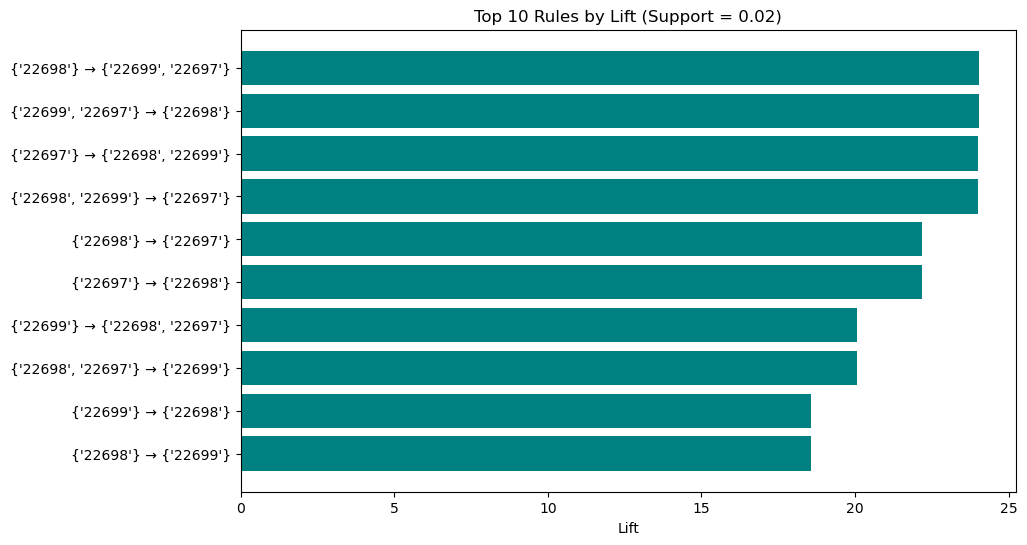

In [44]:
import matplotlib.pyplot as plt

top10_lift = top_lift.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    range(len(top10_lift)),
    top10_lift["lift"],
    color="teal"
)
plt.gca().invert_yaxis()
plt.yticks(
    range(len(top10_lift)),
    top10_lift.apply(lambda row: f"{set(row['antecedents'])} → {set(row['consequents'])}", axis=1)
)
plt.title("Top 10 Rules by Lift (Support = 0.02)")
plt.xlabel("Lift")
plt.show()

## Interpretation
The rules reveal very strong co-purchasing patterns, especially among items 22697, 22698, and 22699. These three codes frequently appear together and dominate the top-lift and top-confidence rankings.

### Five Business-Relevant, Meaningful Rules

1. {22698} → {22697, 22699}  
   - Customers buying item 22698 often purchase the other two.  
   - Lift ≈ 24 indicates a strong dependency.  
   - Suggests a 3-piece product set that can be bundled or cross-promoted.

2. {22697, 22699} → {22698}  
   - Reverse of rule #1; forms a closed product trio.  
   - Indicates reliable cross-selling potential.

3. {22699} → {22697}  
   - Strong pairwise association.  
   - Appropriate for “buy together” recommendations.

4. {22697} → {22698}  
   - High-confidence pair that frequently co-occurs.  
   - Useful for recommender systems.

5. {22699, 22698} → {22697}  
   - Completes the three-item set.  
   - Reinforces the presence of a cohesive product family.

### Two Rules That Are Potentially Misleading or Spurious

1. Rules with high confidence but lift close to 1  
   - These reflect general popularity rather than a meaningful relationship.  
   - They appear strong but provide little insight for cross-selling.

2. Rules with extremely low support  
   - Rare transactions can artificially inflate lift and confidence.  
   - Not actionable because the pattern is not common across customers.

### Threshold Sensitivity: How Support and Confidence Affect Results

#### Effect of Increasing Support (0.02 to 0.03)
- Frequent itemsets drop from 251 to 94.  
- Multi-item sets disappear entirely.  
- Rule count falls from 79 to 0.  
Takeaway: High support thresholds remove rare but meaningful associations, leaving only trivial single-item patterns.

#### Effect of Increasing Confidence
- Produces fewer rules.  
- Remaining rules become more obvious and popularity-driven.  
- Improves clarity but reduces discovery of novel relationships.

#### Effect on Average Rule Length
- At 2% support, average rule length is about 2.08.  
- At 3% support, only singletons remain.

### Overall Interpretability and Actionability
- Low support (less than or equal to 2%) produces many rules with richer insights but requires filtering.  
- Moderate support (2 to 3%) provides the best balance.  
- High support (greater than 3%) becomes too restrictive and eliminates nearly all structure/interesting patterns.

### Final Summary
- The dataset highlights a strong product trio: 22697, 22698, and 22699.  
- These associations support bundling, recommendations, and merchandising strategies.  
- Some rules are misleading due to low support or trivial lift values.  
- Rule quality and quantity change significantly with threshold adjustments.  
- Apriori at 2% support offers the most informative balance for this dataset.


## Conclusions: Key Takeaways, Risks, and Next Steps

### Key Takeaways
- The clustering dataset forms a mostly continuous feature space with no distinct natural clusters.  
  - K-means, HAC, DBSCAN, Spectral, and GMM all show weak structure with optimal k around 2 and low silhouette scores.  
  - External metrics indicate minimal alignment between clusters and disease_risk labels.

- PCA and correlation analysis show that health features vary smoothly along linear trends such as age, blood pressure, and cholesterol, suggesting that disease risk behaves more like a continuous variable.

- The transactional dataset, in contrast, displays clear and actionable associations.  
  - The repeated appearance of the 22697–22698–22699 item trio indicates strong co-purchasing patterns suitable for bundling and recommendations.

- Threshold sensitivity is crucial:  
  - Support at 2% preserves meaningful multi-item sets.  
  - Support at or above 3% collapses itemsets to singletons and eliminates rule generation.

### Risks and Limitations
- The clustering dataset is synthetic, so patterns may not reflect real-world populations.  
- Clustering outcomes depend heavily on feature scaling, correlations, dimensionality, and the distance metric. DBSCAN and graph-based clustering failed due to the lack of true density-separated structure.
- Association rule mining can produce misleading rules driven by item popularity rather than true relationships. Rules based on rare items also tend to be unstable and not actionable.

- FP-growth was slightly slower than Apriori due to the dataset’s density; performance differences may vary with other datasets.

### Next Steps
- For clustering:
  - Explore nonlinear dimensionality reduction (UMAP, t-SNE) to detect subtle structures.  
  - Improve feature engineering using ratios or composite health scores.  
  - Consider supervised approaches for modeling disease_risk.

- For association rules:
  - Incorporate price, quantity, or temporal patterns (e.g., seasonality).  
  - Build a recommendation engine using discovered rules.  
  - Experiment with lower support thresholds (1 to 2%) for deeper insights.

- For deployment:
  - Combine association rules with customer segmentation to enable personalized marketing.  
  - Validate questionable rules using product metadata or category information.
